In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("merged_pressure_data.csv")

In [ ]:
df.replace(9999999999, np.nan, inplace=True)

df = df.dropna(subset=["BAROCAP1_PRESSURE"])

In [ ]:
print("Sol Range:", df["sol"].min(), "to", df["sol"].max())
print("Total unique sols:", df["sol"].nunique())

Sol Range: 1.0 to 30.0
Total unique sols: 16


In [ ]:
sol_pressure = df.groupby("sol")["BAROCAP1_PRESSURE"].mean().reset_index()

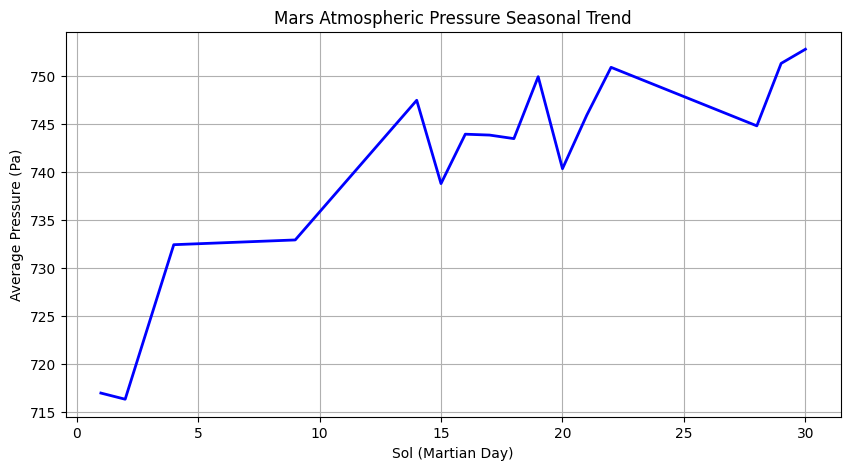

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(sol_pressure["sol"],
         sol_pressure["BAROCAP1_PRESSURE"],
         color="blue",
         linewidth=2)

plt.xlabel("Sol (Martian Day)")
plt.ylabel("Average Pressure (Pa)")
plt.title("Mars Atmospheric Pressure Seasonal Trend")

plt.grid(True)

plt.show()

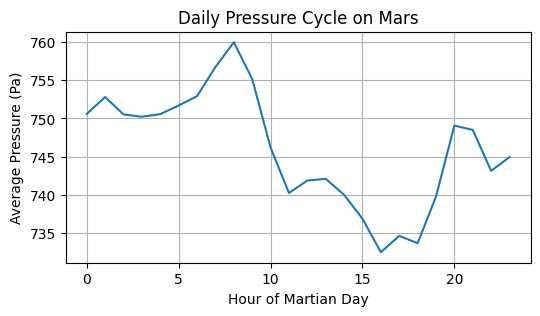

In [ ]:
df["hour"] = df["LMST"].str.split("M").str[1].str.split(":").str[0].astype(int)

hourly_pressure = df.groupby("hour")["BAROCAP1_PRESSURE"].mean()

plt.figure(figsize=(6,3))

plt.plot(hourly_pressure)

plt.xlabel("Hour of Martian Day")
plt.ylabel("Average Pressure (Pa)")
plt.title("Daily Pressure Cycle on Mars")

plt.grid(True)

plt.show()

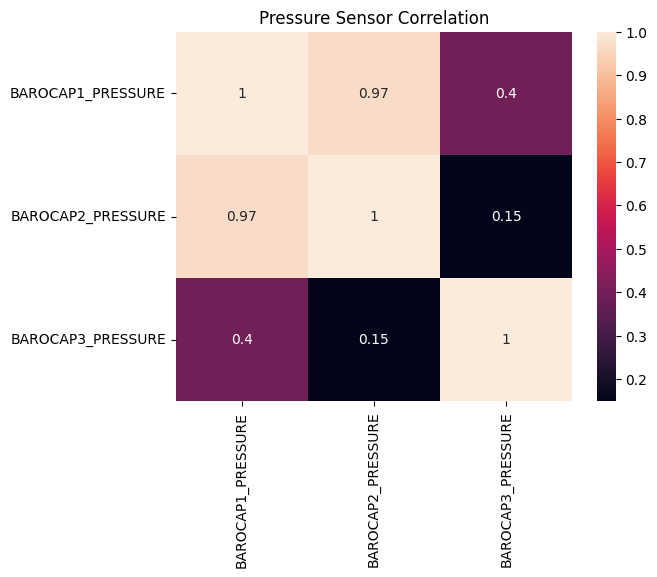

<Figure size 500x500 with 0 Axes>

In [ ]:
import seaborn as sns

corr = df[[
    "BAROCAP1_PRESSURE",
    "BAROCAP2_PRESSURE",
    "BAROCAP3_PRESSURE"
]].corr()

sns.heatmap(corr, annot=True)

plt.title("Pressure Sensor Correlation")
plt.figure(figsize=(5,5))

plt.show()

In [ ]:
df["pressure_change"] = df["BAROCAP1_PRESSURE"].diff()

threshold = df["pressure_change"].mean() - 3*df["pressure_change"].std()

storms = df[df["pressure_change"] < threshold]

print("Number of potential storm events:", len(storms))

Number of potential storm events: 175


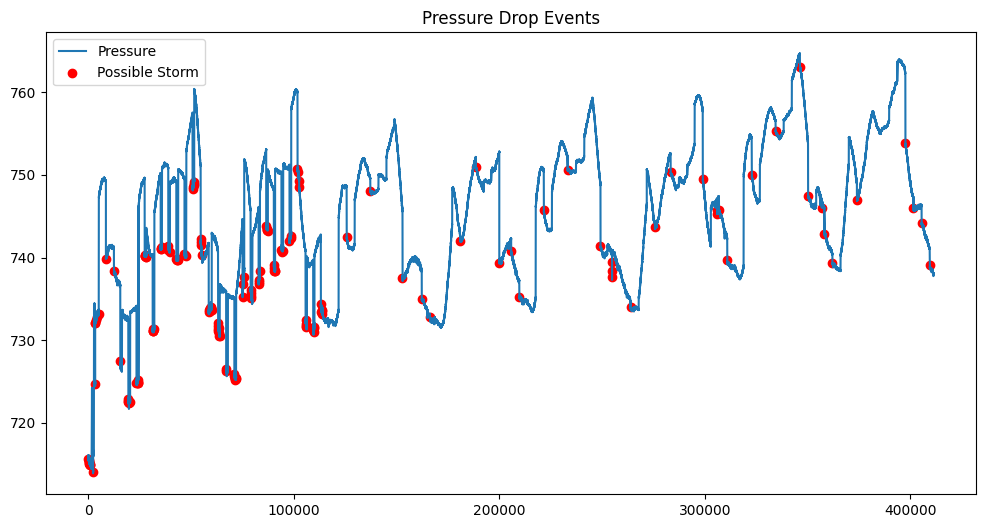

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(df["BAROCAP1_PRESSURE"], label="Pressure")

plt.scatter(storms.index,
            storms["BAROCAP1_PRESSURE"],
            color="red",
            label="Possible Storm")

plt.legend()
plt.title("Pressure Drop Events")

plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("merged_pressure_data.csv")

# remove invalid values
df.replace(9999999999, np.nan, inplace=True)

df = df.dropna(subset=["BAROCAP1_PRESSURE"])

In [ ]:
df["hour"] = df["LMST"].str.split("M").str[1].str.split(":").str[0].astype(int)

In [ ]:
hourly_pressure = df.groupby(["sol","hour"])["BAROCAP1_PRESSURE"].mean().reset_index()

In [ ]:
hourly_pressure["time_index"] = range(len(hourly_pressure))

In [ ]:
hourly_pressure["pressure_change"] = hourly_pressure["BAROCAP1_PRESSURE"].diff()

In [ ]:
mean_change = hourly_pressure["pressure_change"].mean()
std_change = hourly_pressure["pressure_change"].std()

threshold = mean_change - 2.5 * std_change

storms = hourly_pressure[hourly_pressure["pressure_change"] < threshold]

print("Detected storm events:", len(storms))

Detected storm events: 28


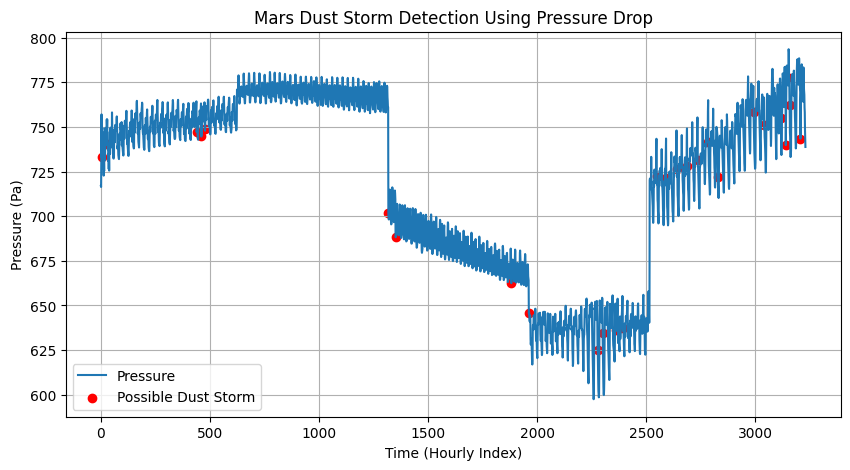

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(hourly_pressure["time_index"],
         hourly_pressure["BAROCAP1_PRESSURE"],
         label="Pressure")

plt.scatter(storms["time_index"],
            storms["BAROCAP1_PRESSURE"],
            color="red",
            label="Possible Dust Storm")

plt.xlabel("Time (Hourly Index)")
plt.ylabel("Pressure (Pa)")
plt.title("Mars Dust Storm Detection Using Pressure Drop")

plt.legend()
plt.grid(True)

plt.show()

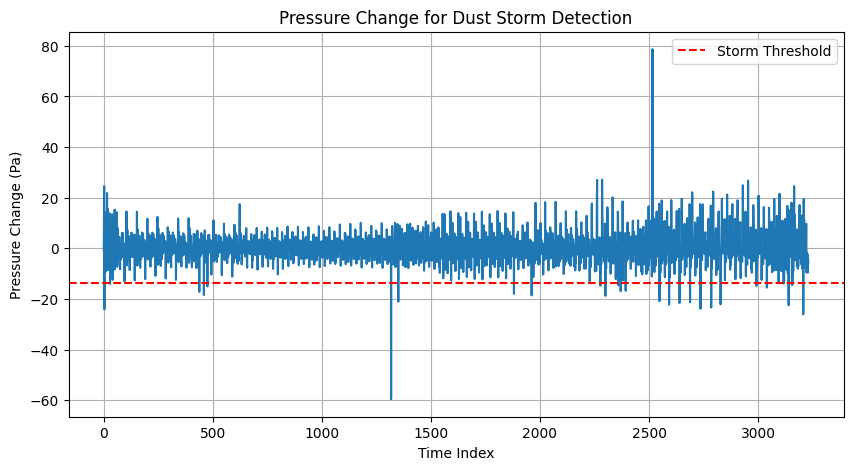

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(hourly_pressure["pressure_change"])

plt.axhline(threshold, color="red", linestyle="--", label="Storm Threshold")

plt.title("Pressure Change for Dust Storm Detection")

plt.xlabel("Time Index")
plt.ylabel("Pressure Change (Pa)")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense

In [ ]:
df = pd.read_csv("merged_pressure_data.csv")

# clean invalid values
df.replace(9999999999, np.nan, inplace=True)

# keep only required column
df = df.dropna(subset=["BAROCAP1_PRESSURE"])

# extract hour
df["hour"] = df["LMST"].str.split("M").str[1].str.split(":").str[0].astype(int)

In [ ]:
hourly = df.groupby(["sol","hour"])["BAROCAP1_PRESSURE"].mean().reset_index()

# create time index
hourly["time_index"] = range(len(hourly))

In [ ]:
scaler = MinMaxScaler()

pressure_scaled = scaler.fit_transform(hourly[["BAROCAP1_PRESSURE"]])

In [ ]:
def create_sequences(data, seq_len):
    X, y = [], []

    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])

    return np.array(X), np.array(y)

seq_length = 24

X, y = create_sequences(pressure_scaled, seq_length)

In [ ]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
lstm_model = Sequential()

lstm_model.add(LSTM(50, input_shape=(seq_length,1)))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer="adam", loss="mse")

lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0277 - val_loss: 0.0048
Epoch 2/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0021 - val_loss: 0.0048
Epoch 3/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0020 - val_loss: 0.0048
Epoch 4/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0020 - val_loss: 0.0046
Epoch 5/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0020 - val_loss: 0.0049
Epoch 6/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0020 - val_loss: 0.0045
Epoch 7/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0020 - val_loss: 0.0045
Epoch 8/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0019 - val_loss: 0.0043
Epoch 9/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0019 - val_loss: 0.0043
Epoch 10/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0018 - val_loss: 0.0041
Epoch 11/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0018 - val_loss: 0.0043
Epoch 12/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0

In [ ]:
gru_model = Sequential()

gru_model.add(GRU(50, input_shape=(seq_length,1)))
gru_model.add(Dense(1))

gru_model.compile(optimizer="adam", loss="mse")

gru_history = gru_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0531 - val_loss: 0.0046
Epoch 2/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0027 - val_loss: 0.0039
Epoch 3/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0017 - val_loss: 0.0034
Epoch 4/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0015 - val_loss: 0.0030
Epoch 5/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0014 - val_loss: 0.0026
Epoch 6/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0013 - val_loss: 0.0024
Epoch 7/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0012 - val_loss: 0.0022
Epoch 8/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0012 - val_loss: 0.0021
Epoch 9/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0011 - val_loss: 0.0020
Epoch 10/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0011 - val_loss: 0.0019
Epoch 11/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0010 - val_loss: 0.0019
Epoch 12/20
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0

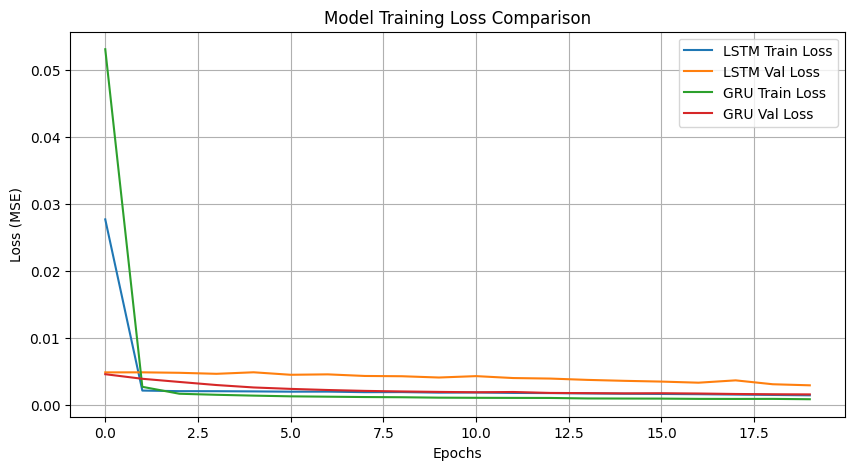

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(lstm_history.history["loss"], label="LSTM Train Loss")
plt.plot(lstm_history.history["val_loss"], label="LSTM Val Loss")

plt.plot(gru_history.history["loss"], label="GRU Train Loss")
plt.plot(gru_history.history["val_loss"], label="GRU Val Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Model Training Loss Comparison")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
lstm_pred = lstm_model.predict(X_test)
gru_pred = gru_model.predict(X_test)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [ ]:
y_test_actual = scaler.inverse_transform(y_test)
lstm_pred_actual = scaler.inverse_transform(lstm_pred)
gru_pred_actual = scaler.inverse_transform(gru_pred)

In [ ]:
def evaluate(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred)/y_true)) * 100

    return mae, rmse, r2, mape

lstm_results = evaluate(y_test_actual, lstm_pred_actual)
gru_results = evaluate(y_test_actual, gru_pred_actual)

print("LSTM:", lstm_results)
print("GRU :", gru_results)

LSTM: (8.90319714736781, np.float64(10.573359931504239), 0.7379558768284167, np.float64(1.1950962362162694))
GRU : (6.008833109233468, np.float64(7.728546812133166), 0.859994829425206, np.float64(0.8062687942458523))


In [ ]:
results = pd.DataFrame({
    "Model": ["LSTM", "GRU"],
    "MAE": [lstm_results[0], gru_results[0]],
    "RMSE": [lstm_results[1], gru_results[1]],
    "R2 Score": [lstm_results[2], gru_results[2]],
    "MAPE (%)": [lstm_results[3], gru_results[3]]
})

print(results)

  Model       MAE       RMSE  R2 Score  MAPE (%)
0  LSTM  8.903197  10.573360  0.737956  1.195096
1   GRU  6.008833   7.728547  0.859995  0.806269


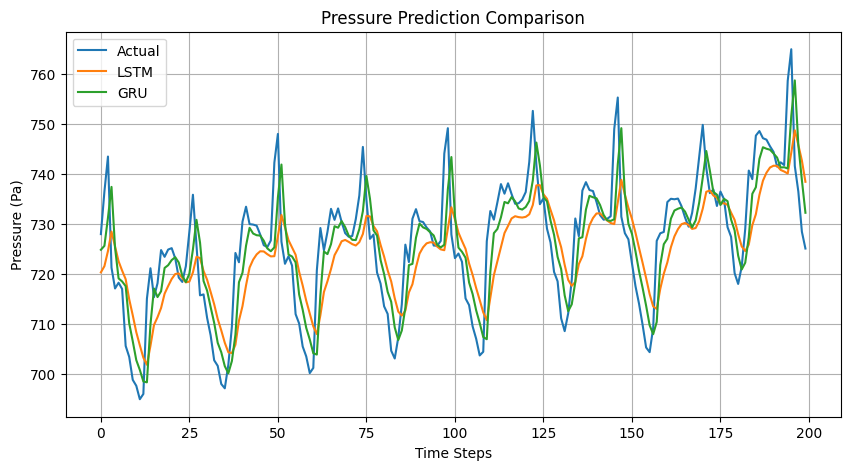

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(y_test_actual[:200], label="Actual")

plt.plot(lstm_pred_actual[:200], label="LSTM")

plt.plot(gru_pred_actual[:200], label="GRU")

plt.xlabel("Time Steps")
plt.ylabel("Pressure (Pa)")
plt.title("Pressure Prediction Comparison")

plt.legend()
plt.grid(True)

plt.show()